In [5]:
import matplotlib.pyplot as plt
import heapq
# Define the 20 samples with schedule thresholds and max_tokens.
Uniform_Set = {
    "sample1":  {"prompt": "Uniform prompt 1",  "max_tokens": 1000, "schedule_at_step": 0},
    "sample2":  {"prompt": "Uniform prompt 2",  "max_tokens": 1000, "schedule_at_step": 0},
    "sample3":  {"prompt": "Uniform prompt 3",  "max_tokens": 1000, "schedule_at_step": 0},
    "sample4":  {"prompt": "Uniform prompt 4",  "max_tokens": 1000, "schedule_at_step": 0},
    "sample5":  {"prompt": "Uniform prompt 5",  "max_tokens": 1000, "schedule_at_step": 500},
    "sample6":  {"prompt": "Uniform prompt 6",  "max_tokens": 1000, "schedule_at_step": 1000},
    "sample7":  {"prompt": "Uniform prompt 7",  "max_tokens": 1000, "schedule_at_step": 1500},
    "sample8":  {"prompt": "Uniform prompt 8",  "max_tokens": 1000, "schedule_at_step": 2000},
    "sample9":  {"prompt": "Uniform prompt 9",  "max_tokens": 1000, "schedule_at_step": 2500},
    "sample10": {"prompt": "Uniform prompt 10", "max_tokens": 1000, "schedule_at_step": 3000},
    "sample11": {"prompt": "Uniform prompt 11", "max_tokens": 1000, "schedule_at_step": 3500},
    "sample12": {"prompt": "Uniform prompt 12", "max_tokens": 1000, "schedule_at_step": 4000},
    "sample13": {"prompt": "Uniform prompt 13", "max_tokens": 1000, "schedule_at_step": 4500},
    "sample14": {"prompt": "Uniform prompt 14", "max_tokens": 1000, "schedule_at_step": 5000},
    "sample15": {"prompt": "Uniform prompt 15", "max_tokens": 1000, "schedule_at_step": 5500},
    "sample16": {"prompt": "Uniform prompt 16", "max_tokens": 1000, "schedule_at_step": 6000},
    "sample17": {"prompt": "Uniform prompt 17", "max_tokens": 1000, "schedule_at_step": 6500},
    "sample18": {"prompt": "Uniform prompt 18", "max_tokens": 1000, "schedule_at_step": 7000},
    "sample19": {"prompt": "Uniform prompt 19", "max_tokens": 1000, "schedule_at_step": 7500},
    "sample20": {"prompt": "Uniform prompt 20", "max_tokens": 1000, "schedule_at_step": 8000},
}
Moderately_Uniform_Set = {
    "sample1":  {"prompt": "ModUniform prompt 1",  "max_tokens": 1100, "schedule_at_step": 0},
    "sample2":  {"prompt": "ModUniform prompt 2",  "max_tokens": 1000, "schedule_at_step": 0},
    "sample3":  {"prompt": "ModUniform prompt 3",  "max_tokens": 1100, "schedule_at_step": 0},
    "sample4":  {"prompt": "ModUniform prompt 4",  "max_tokens": 1000, "schedule_at_step": 0},
    "sample5":  {"prompt": "ModUniform prompt 5",  "max_tokens": 1100, "schedule_at_step": 500},
    "sample6":  {"prompt": "ModUniform prompt 6",  "max_tokens": 1000, "schedule_at_step": 700},
    "sample7":  {"prompt": "ModUniform prompt 7",  "max_tokens": 1100, "schedule_at_step": 900},
    "sample8":  {"prompt": "ModUniform prompt 8",  "max_tokens": 1000, "schedule_at_step": 1100},
    "sample9":  {"prompt": "ModUniform prompt 9",  "max_tokens": 1100, "schedule_at_step": 1300},
    "sample10": {"prompt": "ModUniform prompt 10", "max_tokens": 1000, "schedule_at_step": 1500},
    "sample11": {"prompt": "ModUniform prompt 11", "max_tokens": 1100, "schedule_at_step": 1700},
    "sample12": {"prompt": "ModUniform prompt 12", "max_tokens": 1000, "schedule_at_step": 1900},
    "sample13": {"prompt": "ModUniform prompt 13", "max_tokens": 1100, "schedule_at_step": 2100},
    "sample14": {"prompt": "ModUniform prompt 14", "max_tokens": 1000, "schedule_at_step": 2300},
    "sample15": {"prompt": "ModUniform prompt 15", "max_tokens": 1100, "schedule_at_step": 2500},
    "sample16": {"prompt": "ModUniform prompt 16", "max_tokens": 1000, "schedule_at_step": 2700},
    "sample17": {"prompt": "ModUniform prompt 17", "max_tokens": 1100, "schedule_at_step": 2900},
    "sample18": {"prompt": "ModUniform prompt 18", "max_tokens": 1000, "schedule_at_step": 3100},
    "sample19": {"prompt": "ModUniform prompt 19", "max_tokens": 1100, "schedule_at_step": 3300},
    "sample20": {"prompt": "ModUniform prompt 20", "max_tokens": 1000, "schedule_at_step": 3500},
}
Somewhat_Diverse_Set = {
    "sample1":  {"prompt": "Somewhat diverse prompt 1",  "max_tokens": 1100, "schedule_at_step": 0},
    "sample2":  {"prompt": "Somewhat diverse prompt 2",  "max_tokens": 1100, "schedule_at_step": 0},
    "sample3":  {"prompt": "Somewhat diverse prompt 3",  "max_tokens": 1100, "schedule_at_step": 0},
    "sample4":  {"prompt": "Somewhat diverse prompt 4",  "max_tokens": 1100, "schedule_at_step": 0},
    "sample5":  {"prompt": "Somewhat diverse prompt 5",  "max_tokens": 900,  "schedule_at_step": 200},
    "sample6":  {"prompt": "Somewhat diverse prompt 6",  "max_tokens": 1200, "schedule_at_step": 300},
    "sample7":  {"prompt": "Somewhat diverse prompt 7",  "max_tokens": 1000, "schedule_at_step": 600},
    "sample8":  {"prompt": "Somewhat diverse prompt 8",  "max_tokens": 1400, "schedule_at_step": 650},
    "sample9":  {"prompt": "Somewhat diverse prompt 9",  "max_tokens": 1300, "schedule_at_step": 800},
    "sample10": {"prompt": "Somewhat diverse prompt 10", "max_tokens": 900,  "schedule_at_step": 850},
    "sample11": {"prompt": "Somewhat diverse prompt 11", "max_tokens": 1500, "schedule_at_step": 1200},
    "sample12": {"prompt": "Somewhat diverse prompt 12", "max_tokens": 1200, "schedule_at_step": 1300},
    "sample13": {"prompt": "Somewhat diverse prompt 13", "max_tokens": 800,  "schedule_at_step": 1350},
    "sample14": {"prompt": "Somewhat diverse prompt 14", "max_tokens": 1500, "schedule_at_step": 1600},
    "sample15": {"prompt": "Somewhat diverse prompt 15", "max_tokens": 1400, "schedule_at_step": 1650},
    "sample16": {"prompt": "Somewhat diverse prompt 16", "max_tokens": 1100, "schedule_at_step": 2000},
    "sample17": {"prompt": "Somewhat diverse prompt 17", "max_tokens": 1300, "schedule_at_step": 2100},
    "sample18": {"prompt": "Somewhat diverse prompt 18", "max_tokens": 900,  "schedule_at_step": 2200},
    "sample19": {"prompt": "Somewhat diverse prompt 19", "max_tokens": 1500, "schedule_at_step": 2300},
    "sample20": {"prompt": "Somewhat diverse prompt 20", "max_tokens": 1400, "schedule_at_step": 2400},
}
Diverse_Set = {
    "sample1":  {"prompt": "Diverse prompt 1",  "max_tokens": 900,  "schedule_at_step": 0},
    "sample2":  {"prompt": "Diverse prompt 2",  "max_tokens": 1100, "schedule_at_step": 0},
    "sample3":  {"prompt": "Diverse prompt 3",  "max_tokens": 1000, "schedule_at_step": 0},
    "sample4":  {"prompt": "Diverse prompt 4",  "max_tokens": 950,  "schedule_at_step": 0},
    "sample5":  {"prompt": "Diverse prompt 5",  "max_tokens": 1200, "schedule_at_step": 150},
    "sample6":  {"prompt": "Diverse prompt 6",  "max_tokens": 1300, "schedule_at_step": 300},
    "sample7":  {"prompt": "Diverse prompt 7",  "max_tokens": 800,  "schedule_at_step": 450},
    "sample8":  {"prompt": "Diverse prompt 8",  "max_tokens": 1500, "schedule_at_step": 700},
    "sample9":  {"prompt": "Diverse prompt 9",  "max_tokens": 1400, "schedule_at_step": 750},
    "sample10": {"prompt": "Diverse prompt 10", "max_tokens": 1000, "schedule_at_step": 900},
    "sample11": {"prompt": "Diverse prompt 11", "max_tokens": 1100, "schedule_at_step": 950},
    "sample12": {"prompt": "Diverse prompt 12", "max_tokens": 900,  "schedule_at_step": 1100},
    "sample13": {"prompt": "Diverse prompt 13", "max_tokens": 1600, "schedule_at_step": 1300},
    "sample14": {"prompt": "Diverse prompt 14", "max_tokens": 1500, "schedule_at_step": 1400},
    "sample15": {"prompt": "Diverse prompt 15", "max_tokens": 1400, "schedule_at_step": 1600},
    "sample16": {"prompt": "Diverse prompt 16", "max_tokens": 1700, "schedule_at_step": 1800},
    "sample17": {"prompt": "Diverse prompt 17", "max_tokens": 900,  "schedule_at_step": 1850},
    "sample18": {"prompt": "Diverse prompt 18", "max_tokens": 2000, "schedule_at_step": 2000},
    "sample19": {"prompt": "Diverse prompt 19", "max_tokens": 1300, "schedule_at_step": 2200},
    "sample20": {"prompt": "Diverse prompt 20", "max_tokens": 1500, "schedule_at_step": 2400},
}
Highly_Diverse_Set = {
    "sample1":  {"prompt": "Highly diverse prompt 1",  "max_tokens": 950,  "schedule_at_step": 0},
    "sample2":  {"prompt": "Highly diverse prompt 2",  "max_tokens": 1050, "schedule_at_step": 0},
    "sample3":  {"prompt": "Highly diverse prompt 3",  "max_tokens": 900,  "schedule_at_step": 0},
    "sample4":  {"prompt": "Highly diverse prompt 4",  "max_tokens": 1200, "schedule_at_step": 0},
    "sample5":  {"prompt": "Highly diverse prompt 5",  "max_tokens": 800,  "schedule_at_step": 50},
    "sample6":  {"prompt": "Highly diverse prompt 6",  "max_tokens": 1400, "schedule_at_step": 120},
    "sample7":  {"prompt": "Highly diverse prompt 7",  "max_tokens": 1000, "schedule_at_step": 250},
    "sample8":  {"prompt": "Highly diverse prompt 8",  "max_tokens": 1150, "schedule_at_step": 260},
    "sample9":  {"prompt": "Highly diverse prompt 9",  "max_tokens": 900,  "schedule_at_step": 420},
    "sample10": {"prompt": "Highly diverse prompt 10", "max_tokens": 1300, "schedule_at_step": 500},
    "sample11": {"prompt": "Highly diverse prompt 11", "max_tokens": 800,  "schedule_at_step": 510},
    "sample12": {"prompt": "Highly diverse prompt 12", "max_tokens": 1500, "schedule_at_step": 700},
    "sample13": {"prompt": "Highly diverse prompt 13", "max_tokens": 950,  "schedule_at_step": 740},
    "sample14": {"prompt": "Highly diverse prompt 14", "max_tokens": 1600, "schedule_at_step": 900},
    "sample15": {"prompt": "Highly diverse prompt 15", "max_tokens": 1250, "schedule_at_step": 960},
    "sample16": {"prompt": "Highly diverse prompt 16", "max_tokens": 900,  "schedule_at_step": 1100},
    "sample17": {"prompt": "Highly diverse prompt 17", "max_tokens": 2000, "schedule_at_step": 1150},
    "sample18": {"prompt": "Highly diverse prompt 18", "max_tokens": 1100, "schedule_at_step": 1300},
    "sample19": {"prompt": "Highly diverse prompt 19", "max_tokens": 1400, "schedule_at_step": 1450},
    "sample20": {"prompt": "Highly diverse prompt 20", "max_tokens": 1600, "schedule_at_step": 1600},
}


In [35]:
def plot(DEFAULT_PROMPTS):
    # Simulation parameters
    BATCH_SIZE = 4  # Maximum concurrent requests

    # We'll simulate scheduling using a min-heap of finish times.
    # For each request (processed in order of arrival), if fewer than BATCH_SIZE requests are running,
    # it is scheduled immediately (actual_start = arrival).
    # Otherwise, its actual start time is the maximum of its arrival and the earliest finish time among running requests.
    heap = []  # min-heap for finish times of active requests
    simulation_results = {}  # Dictionary to store computed times for each sample

    # Process requests in order of arrival (schedule_at_step)
    sorted_requests = sorted(DEFAULT_PROMPTS.items(), key=lambda x: x[1]["arrive_at_step"])

    for sample_id, sample in sorted_requests:
        arrival = sample["arrive_at_step"]
        processing_time = sample["max_tokens"]  # Use max_tokens as a proxy for processing duration
        
        if len(heap) < BATCH_SIZE:
            # There is a free slot – start immediately.
            actual_start = arrival
        else:
            # All slots are busy: wait until the earliest one finishes.
            earliest_finish = heapq.heappop(heap)
            actual_start = max(arrival, earliest_finish)
        finish = actual_start + processing_time
        # Push this request's finish time into the heap.
        heapq.heappush(heap, finish)
        wait_time = actual_start - arrival
        simulation_results[sample_id] = {
            "arrival": arrival,
            "start": actual_start,
            "finish": finish,
            "wait": wait_time,
            "processing": processing_time
        }

    # Visualization
    fig, ax = plt.subplots(figsize=(10, 8))

    # For clear ordering, sort sample IDs by their arrival time.
    sample_ids_sorted = sorted(simulation_results.keys(),
                            key=lambda sid: simulation_results[sid]["arrival"])
    y_positions = range(len(sample_ids_sorted))  # one row per sample

    for y, sample_id in zip(y_positions, sample_ids_sorted):
        res = simulation_results[sample_id]
        arrival = res["arrival"]
        start = res["start"]
        finish = res["finish"]
        
        # Plot waiting time (if any) as a dashed red segment from arrival to start.
        if start > arrival:
            ax.hlines(y, arrival, start, colors='red', linestyles='dashed', linewidth=4, label="Wait Time" if y==0 else "")
            ax.plot(arrival, y, 'ro')  # Arrival marker (red)
            ax.plot(start, y, 'ro')    # Start marker (red)
        else:
            # No wait time; mark arrival/start with a green dot.
            ax.plot(arrival, y, 'go', label="No Wait" if y==0 else "")
        
        # Plot processing period as a solid blue segment from actual_start to finish.
        ax.hlines(y, start, finish, colors='blue', linewidth=4, label="Processing Time" if y==0 else "")
        ax.plot(finish, y, 'ko')  # Finish marker (black)

    ax.set_xlabel("Cumulative Tokens (Time Units)")
    ax.set_ylabel("Sample ID")
    ax.set_title("Request Lifetime with Wait Time Incorporated")
    ax.set_yticks(list(y_positions))
    ax.set_yticklabels(sample_ids_sorted)
    ax.grid(True)

    # Avoid duplicate legend entries by only showing unique labels.
    handles, labels = ax.get_legend_handles_labels()
    unique = {}
    for h, l in zip(handles, labels):
        if l not in unique:
            unique[l] = h
    ax.legend(unique.values(), unique.keys())

    plt.show()

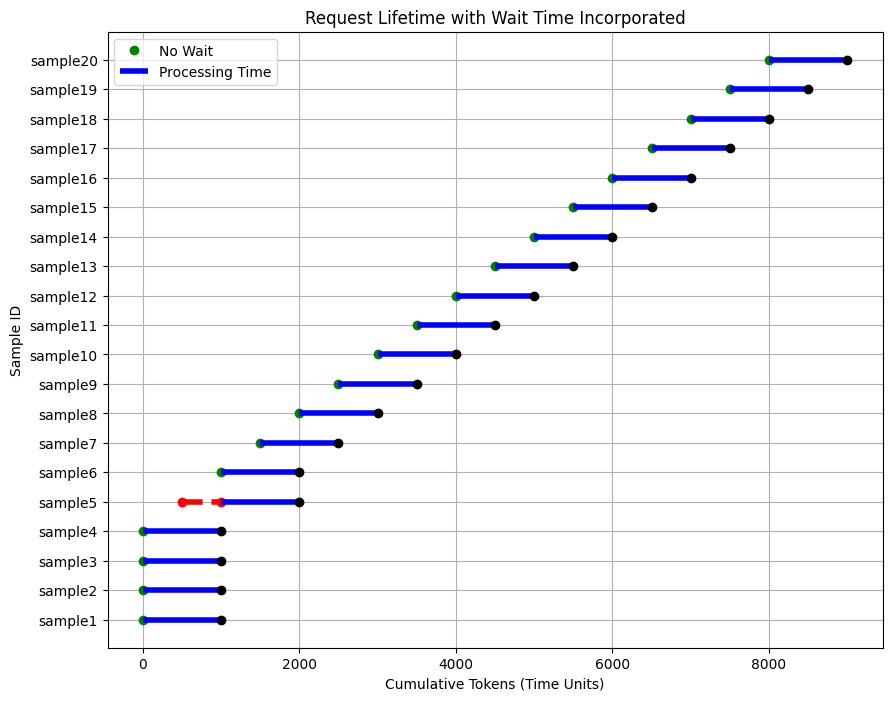

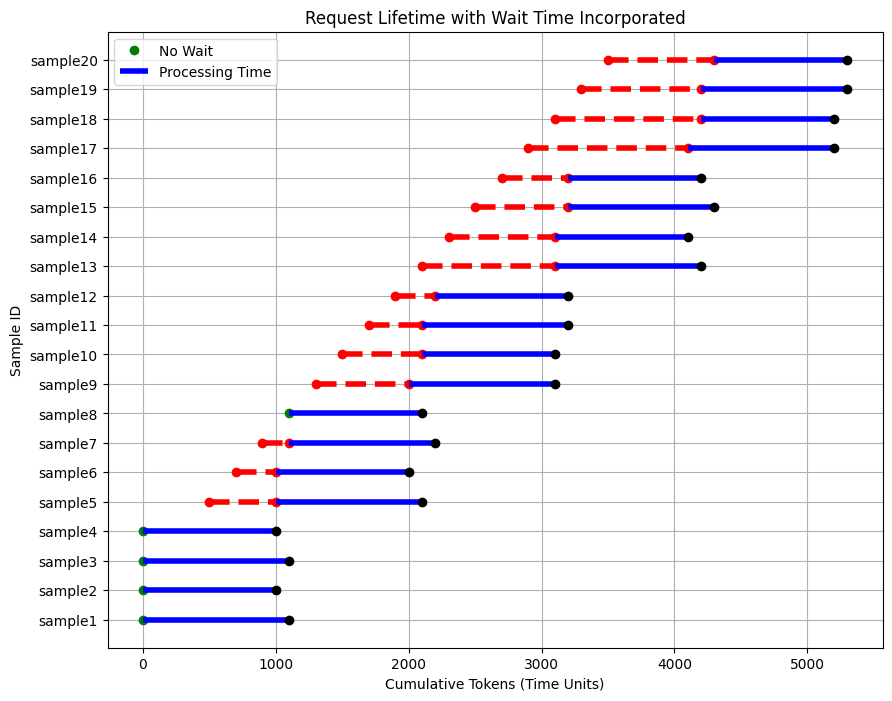

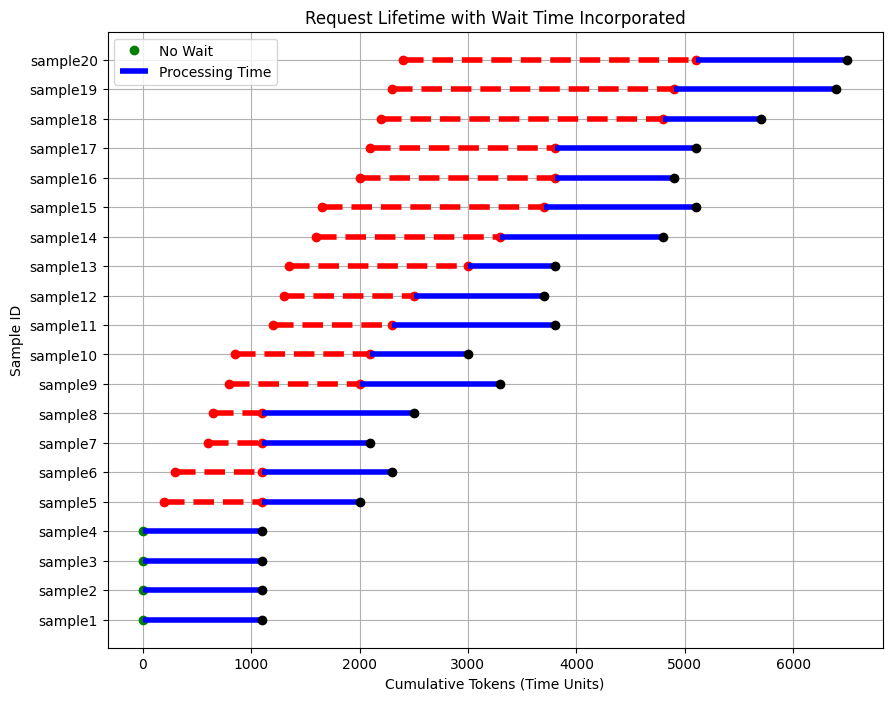

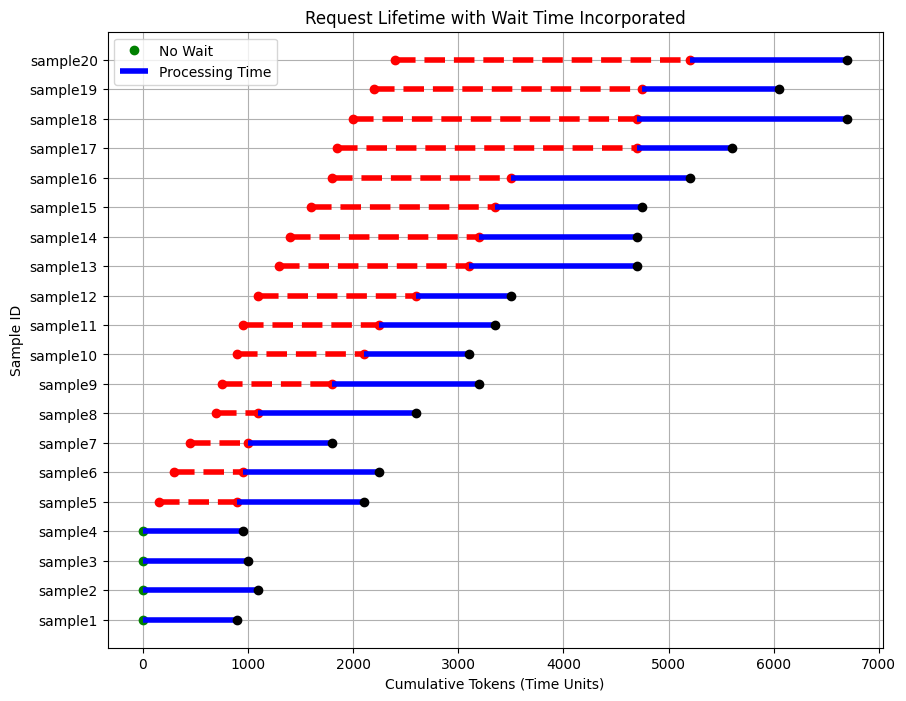

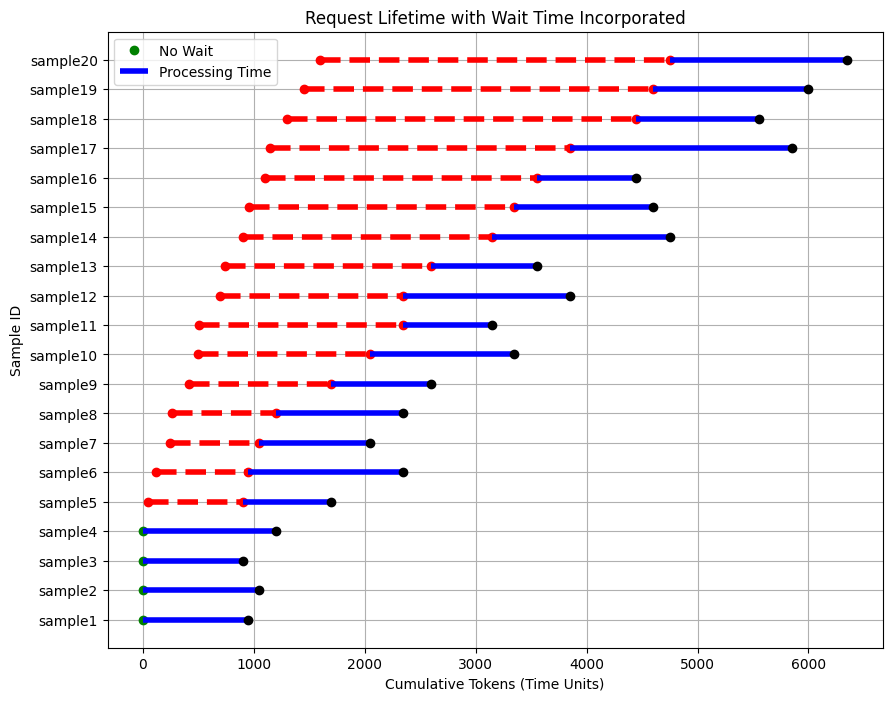

In [31]:
for prompts in [
    Uniform_Set,
    Moderately_Uniform_Set,
    Somewhat_Diverse_Set,
    Diverse_Set,
    Highly_Diverse_Set
]:
    plot(prompts)

In [69]:
csv_path = "/home/xinyuema/vllm/scripts/metrics.csv"
import pandas as pd 
df = pd.read_csv(csv_path) 
print(df.columns)
df['prefill_start'] = df['first_scheduled_time']
df['prefill_end']   = df['first_scheduled_time'] + df['time_to_first_token']

df['decode_start']  = df['prefill_end']
df['decode_end']    = df['finished_time']

df['wait_start']    = df['arrival_time']
df['wait_end']      = df['first_scheduled_time']


Index(['request_id', 'arrival_time', 'first_scheduled_time', 'finished_time',
       'stall_times', 'wait_duration', 'time_to_first_token',
       'scheduler_overehad', 'stall_duration', 'decode_length',
       'end_to_end_time', 'time_per_output_token', 'time_between_tokens',
       'stall_durations'],
      dtype='object')


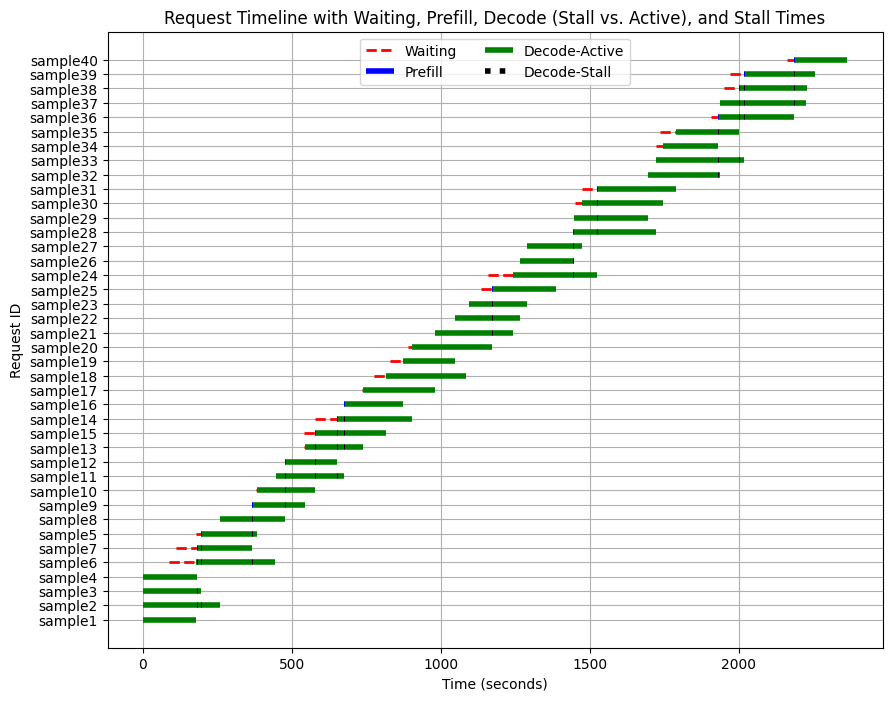

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1) Prepare the DataFrame
# ------------------------------------------------------------------------------
# Suppose df has columns:
#   ['request_id', 'arrival_time', 'first_scheduled_time', 'finished_time',
#    'wait_duration', 'time_to_first_token', 'scheduler_overehad',
#    'stall_duration', 'decode_length', 'end_to_end_time',
#    'time_per_output_token', 'time_between_tokens', 'stall_durations']
#
# Additionally, you’ve added `stall_times` (list or array of times when stalls occur).
#
# We define helper columns for intervals:
df['prefill_start'] = df['first_scheduled_time']
df['prefill_end']   = df['first_scheduled_time'] + df['time_to_first_token']

df['decode_start']  = df['prefill_end']
df['decode_end']    = df['finished_time']

df['wait_start']    = df['arrival_time']
df['wait_end']      = df['first_scheduled_time']

# ------------------------------------------------------------------------------
# 2) Interval merging & overlap helper functions
# ------------------------------------------------------------------------------
def merge_intervals(intervals):
    """Merge a list of (start, end) intervals into a minimal set of non-overlapping intervals."""
    if not intervals:
        return []
    
    intervals_sorted = sorted(intervals, key=lambda x: x[0])
    merged = []
    current_start, current_end = intervals_sorted[0]
    
    for i in range(1, len(intervals_sorted)):
        s, e = intervals_sorted[i]
        if s <= current_end:  # Overlap
            current_end = max(current_end, e)
        else:
            merged.append((current_start, current_end))
            current_start, current_end = s, e
    merged.append((current_start, current_end))
    return merged

def intersect_intervals(interval_a, intervals_b):
    """
    Given a single interval (start_a, end_a) and a list intervals_b (each a tuple of (start, end)),
    return the list of overlapping sub-intervals.
    """
    (start_a, end_a) = interval_a
    overlaps = []
    for (start_b, end_b) in intervals_b:
        overlap_start = max(start_a, start_b)
        overlap_end   = min(end_a, end_b)
        if overlap_start < overlap_end:
            overlaps.append((overlap_start, overlap_end))
    return overlaps

def subtract_intervals(interval_a, intervals_b):
    """
    Subtract intervals_b from interval_a. Return the remaining (non-overlapped) sub-intervals.
    interval_a is a single tuple (start, end), intervals_b is a list of (start, end).
    """
    segments = [interval_a]
    for (b_start, b_end) in intervals_b:
        new_segments = []
        for (s, e) in segments:
            if b_end <= s or b_start >= e:
                # No overlap
                new_segments.append((s, e))
            else:
                # Partial overlap => split
                if b_start > s:
                    new_segments.append((s, b_start))
                if b_end < e:
                    new_segments.append((b_end, e))
        segments = new_segments
    return segments

# ------------------------------------------------------------------------------
# 3) Compute stall vs. active decode segments (by overlap with other requests' prefill)
# ------------------------------------------------------------------------------
requests_info = []

# Precompute the union of *all* prefill intervals for convenience.
# (We’ll subtract out the current request’s own prefill if needed.)
all_prefill_intervals = list(zip(df['prefill_start'], df['prefill_end']))
all_prefill_union = merge_intervals(all_prefill_intervals)

for idx, row in df.iterrows():
    req_id = row['request_id']
    
    # Intervals
    wait_int    = (row['wait_start'],    row['wait_end'])
    prefill_int = (row['prefill_start'], row['prefill_end'])
    decode_int  = (row['decode_start'],  row['decode_end'])
    
    # Build a union of all-other prefill intervals
    other_prefills = []
    for i2, r2 in df.iterrows():
        if i2 != idx:  
            other_prefills.append((r2['prefill_start'], r2['prefill_end']))
    other_prefills_union = merge_intervals(other_prefills)
    
    # Overlaps of decode interval => decode-stall
    decode_stall = intersect_intervals(decode_int, other_prefills_union)
    # The remainder => decode-active
    decode_active = subtract_intervals(decode_int, decode_stall)
    
    # Collect to a structure
    requests_info.append({
        'request_id': req_id,
        'wait_interval': wait_int,
        'prefill_interval': prefill_int,
        'decode_stall_intervals': decode_stall,
        'decode_active_intervals': decode_active,
        # If you’d like to directly use stall_duration or stall_durations:
        # 'stall_duration': row['stall_duration'],
        # 'stall_durations': row['stall_durations'],
        # We will also use stall_times if you want to plot exact stall events:
        'stall_times': row.get('stall_times', None),  # might be a list of time points
    })

# ------------------------------------------------------------------------------
# 4) Sort for a neat plot
# ------------------------------------------------------------------------------
df_sorted = df.sort_values(by='arrival_time').reset_index(drop=True)
# Map request_id => a y-position
id_to_order = {rid: i for i, rid in enumerate(df_sorted['request_id'])}

# ------------------------------------------------------------------------------
# 5) Plot
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

legend_used = set()

for item in requests_info:
    rid = item['request_id']
    y   = id_to_order[rid]  # integer for y-axis
    
    #  -- WAIT (red dashed) --
    w_s, w_e = item['wait_interval']
    if w_e > w_s:
        label = "Waiting" if "Waiting" not in legend_used else None
        ax.hlines(y, w_s, w_e, color='red', linestyle='dashed', linewidth=2, label=label)
        legend_used.add("Waiting")
    
    #  -- PREFILL (blue solid) --
    p_s, p_e = item['prefill_interval']
    if p_e > p_s:
        label = "Prefill" if "Prefill" not in legend_used else None
        ax.hlines(y, p_s, p_e, color='blue', linestyle='solid', linewidth=4, label=label)
        legend_used.add("Prefill")
    
    #  -- DECODE STALL (black dotted) --
    for (stall_s, stall_e) in item['decode_stall_intervals']:
        label = "Decode-Stall" if "Decode-Stall" not in legend_used else None
        ax.hlines(y, stall_s, stall_e, color='black', linestyle='dotted', linewidth=4, label=label)
        legend_used.add("Decode-Stall")
    
    #  -- DECODE ACTIVE (green solid) --
    for (dec_s, dec_e) in item['decode_active_intervals']:
        label = "Decode-Active" if "Decode-Active" not in legend_used else None
        ax.hlines(y, dec_s, dec_e, color='green', linestyle='solid', linewidth=4, label=label)
        legend_used.add("Decode-Active")
    
    #  -- (Optional) MARK EXACT STALL TIMES (if you store them) --
    stall_ts = item['stall_times']
    # If stall_times is a list of numeric times, we can put an 'x' at each:
    if stall_ts and isinstance(stall_ts, (list, tuple)):
        for st_time in stall_ts:
            # Mark each stall time with a black "x"
            lbl = "Stall moment" if "Stall moment" not in legend_used else None
            ax.plot(st_time, y, 'kx', label=lbl)
            legend_used.add("Stall moment")

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Request ID")
ax.set_title("Request Timeline with Waiting, Prefill, Decode (Stall vs. Active), and Stall Times")
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['request_id'])
ax.grid(True)
ax.legend(ncol=2, loc="upper center")
plt.show()



=== CONTINUOUS BATCHING = TRUE ===
sample1: 754, max_tokens=3228, arrive_at_step=0
sample4: 328, max_tokens=3285, arrive_at_step=0
sample3: 381, max_tokens=3501, arrive_at_step=0
sample2: 125, max_tokens=4518, arrive_at_step=0
sample7: 658, max_tokens=3178, arrive_at_step=2070
sample5: 854, max_tokens=3209, arrive_at_step=3229
sample6: 792, max_tokens=4516, arrive_at_step=1651
sample8: 704, max_tokens=3864, arrive_at_step=4519
sample9: 132, max_tokens=3061, arrive_at_step=6439
sample10: 195, max_tokens=3447, arrive_at_step=6681
sample12: 716, max_tokens=3054, arrive_at_step=8384
sample11: 338, max_tokens=4034, arrive_at_step=7803
sample13: 674, max_tokens=3407, arrive_at_step=9501
sample15: 818, max_tokens=4116, arrive_at_step=9522
sample16: 529, max_tokens=3451, arrive_at_step=11838
sample14: 833, max_tokens=4330, arrive_at_step=10129
sample17: 559, max_tokens=4206, arrive_at_step=12909
sample19: 990, max_tokens=3013, arrive_at_step=14512
sample18: 384, max_tokens=4657, arrive_at_ste

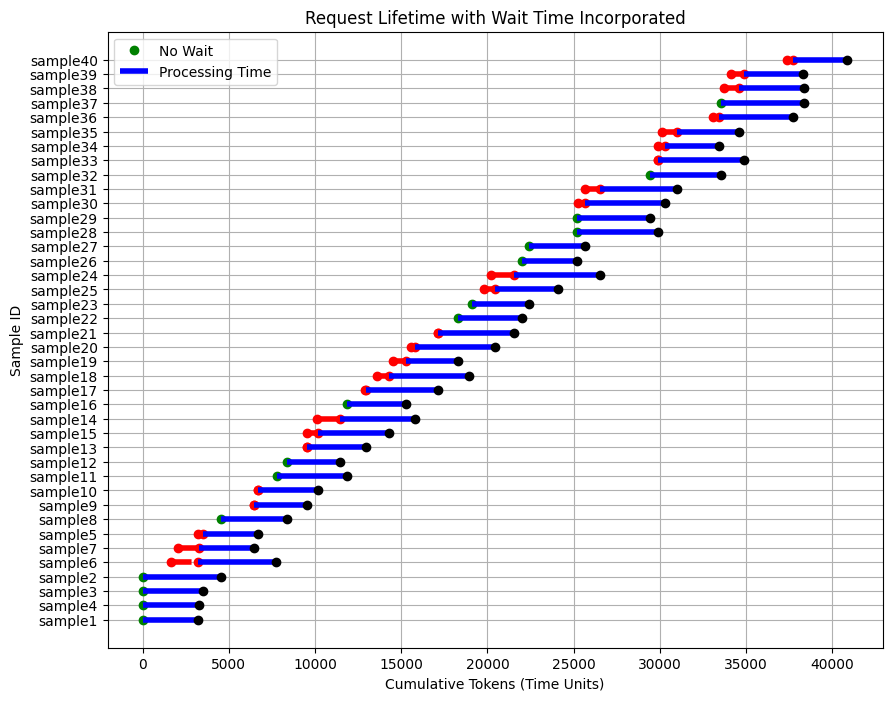

In [66]:
import random
from collections import defaultdict

def generate_trace(
    num_requests: int,
    batch_size: int,
    prompt_len_range: tuple,    # (min_prompt, max_prompt)
    decode_len_range: tuple,    # (min_decode, max_decode)
    fraction_no_wait: float = 0.3,
    alpha: float = 0.5,
    beta: float = 3.0,
    continuous_batching: bool = False,
    seed: int = 42
) -> dict:
    """
    Generates requests with earliest schedule times, then assigns arrival times
    so that a fraction arrive exactly on schedule (no wait), and the rest arrive
    earlier by a random wait in [alpha * total_steps, beta * total_steps].
    
    Then re-simulates with either lockstep or continuous batching to produce
    the final trace.
    """
    random.seed(seed)
    
    # 1) Generate all requests (with random lengths)
    requests = []
    for i in range(1, num_requests + 1):
        p_len = random.randint(prompt_len_range[0], prompt_len_range[1])
        d_len = random.randint(decode_len_range[0], decode_len_range[1])
        requests.append({
            "id": f"sample{i}",
            "prompt_len": p_len,
            "decode_len": d_len,
            "total_steps": 1 + d_len,  # (1 prefill + decode_len)
        })

    # 2) Determine earliest schedule time (ignoring arrival times)
    if continuous_batching:
        earliest_schedule_times = _earliest_schedule_times_continuous(requests, batch_size)
    else:
        earliest_schedule_times = _earliest_schedule_times_lockstep(requests, batch_size)

    # Attach the earliest schedule time to each request
    for req, sched_t in zip(requests, earliest_schedule_times):
        req["earliest_schedule_time"] = sched_t

    # 3) Assign arrival times
    random.shuffle(requests)  # shuffle so we can pick random fraction for "no_wait"
    no_wait_count = int(round(fraction_no_wait * num_requests))
    no_wait_reqs = requests[:no_wait_count]
    wait_reqs    = requests[no_wait_count:]
    
    # 3a) no_wait_reqs => arrive exactly at earliest_schedule_time
    for r in no_wait_reqs:
        r["arrival_step"] = r["earliest_schedule_time"]
    
    # 3b) wait_reqs => arrive_at_step = earliest_schedule_time - random_wait
    for r in wait_reqs:
        t = r["total_steps"]
        wait_amount = random.uniform(alpha * t, beta * t)
        arrival = r["earliest_schedule_time"] - int(wait_amount)
        r["arrival_step"] = max(0, arrival)

    # 4) Sort by arrival time (optional, but helps visualize)
    requests.sort(key=lambda x: x["arrival_step"])

    # 5) Actual final scheduling with arrivals
    if continuous_batching:
        final_trace = _continuous_batching(requests, batch_size)
    else:
        final_trace = _lockstep_batching(requests, batch_size)

    return final_trace

def _earliest_schedule_times_lockstep(requests, batch_size):
    """
    Returns a list of earliest schedule times for each request in the
    given input order (lockstep batching).
    """
    earliest_times = []
    global_step = 0
    idx = 0
    while idx < len(requests):
        sub_batch = requests[idx : idx + batch_size]
        idx += batch_size

        # All in this sub-batch can schedule at global_step
        for _ in sub_batch:
            earliest_times.append(global_step)

        # Then advance global_step
        max_decode = max(r["decode_len"] for r in sub_batch)
        sub_batch_steps = 1 + max_decode
        global_step += sub_batch_steps

    return earliest_times

def _earliest_schedule_times_continuous(requests, batch_size):
    """
    Returns earliest schedule times in 'continuous' mode, ignoring
    arrival times (just fill as soon as a slot is open).
    """
    earliest_times = [None]*len(requests)
    active = []  # list of (finish_time, ireq, start_time)
    current_req_idx = 0
    current_step = 0

    while current_req_idx < len(requests):
        # Remove completed requests
        active = [(fin_t, ireq, st) for (fin_t, ireq, st) in active if fin_t > current_step]

        # Schedule new requests if there's room
        while len(active) < batch_size and current_req_idx < len(requests):
            r = requests[current_req_idx]
            start_time = current_step
            earliest_times[current_req_idx] = start_time
            finish_time = start_time + r["total_steps"]
            active.append((finish_time, current_req_idx, start_time))
            current_req_idx += 1

        if not active:
            current_step += 1
            continue

        # Advance to the next finishing time
        next_fin = min(a[0] for a in active)
        current_step = next_fin

    return earliest_times

def _lockstep_batching(requests, batch_size):
    """
    Real scheduling pass in lockstep mode using assigned arrival_step.
    """
    final_trace = {}
    global_step = 0

    arrivals_dict = defaultdict(list)
    for r in requests:
        arrivals_dict[r["arrival_step"]].append(r)

    sorted_arrivals = sorted(arrivals_dict.keys())
    for arrival_step in sorted_arrivals:
        # The earliest we can schedule is max(global_step, arrival_step)
        schedule_burst_step = max(global_step, arrival_step)
        burst_list = arrivals_dict[arrival_step]

        idx = 0
        while idx < len(burst_list):
            sub_batch = burst_list[idx : idx + batch_size]
            idx += batch_size

            max_decode = max(r["decode_len"] for r in sub_batch)
            sub_batch_steps = 1 + max_decode

            for r_sub in sub_batch:
                a_step = r_sub["arrival_step"]
                s_step = schedule_burst_step
                wait_time = s_step - a_step

                final_trace[r_sub["id"]] = {
                    "prompt": r_sub["prompt_len"],           # integer prompt length
                    "max_tokens": r_sub["decode_len"],
                    "arrive_at_step": a_step,
                    "schedule_at_step": s_step,              # renamed field
                    "wait_time": wait_time,
                }

            global_step = schedule_burst_step + sub_batch_steps

    return final_trace

def _continuous_batching(requests, batch_size):
    """
    Real scheduling pass in continuous mode using assigned arrival_step.
    """
    final_trace = {}
    requests_sorted = sorted(requests, key=lambda r: r["arrival_step"])
    total_reqs = len(requests_sorted)

    active_batch = []  # list of (req_dict, schedule_step, remaining_steps)
    completed_count = 0
    current_step = 0
    next_req_idx = 0

    while completed_count < total_reqs:
        # 1) Fill available slots with newly arrived requests
        while next_req_idx < total_reqs and len(active_batch) < batch_size:
            cand = requests_sorted[next_req_idx]
            if cand["arrival_step"] <= current_step:
                # schedule now
                active_batch.append([cand, current_step, cand["total_steps"]])
                next_req_idx += 1
            else:
                break

        if not active_batch:
            # jump to the next arrival
            next_arrival = requests_sorted[next_req_idx]["arrival_step"]
            current_step = next_arrival
            continue

        # 2) Produce 1 step of progress for each active request
        still_active = []
        finished = []
        for (req_dict, schedule_step, rem_steps) in active_batch:
            new_rem = rem_steps - 1
            if new_rem <= 0:
                finished.append((req_dict, schedule_step))
            else:
                still_active.append([req_dict, schedule_step, new_rem])
        active_batch = still_active

        # 3) Mark finished
        for (req_dict, s_step) in finished:
            completed_count += 1
            a_step = req_dict["arrival_step"]
            wait_time = s_step - a_step
            final_trace[req_dict["id"]] = {
                "prompt": req_dict["prompt_len"],      # integer prompt length
                "max_tokens": req_dict["decode_len"],
                "arrive_at_step": a_step,
                "schedule_at_step": s_step,            # renamed field
                "wait_time": wait_time,
            }

        # 4) Advance step
        current_step += 1

    return final_trace
# ------------------ EXAMPLE USAGE ------------------
if __name__ == "__main__":
    # print("=== CONTINUOUS BATCHING = FALSE (lockstep) ===")
    # lockstep_trace = generate_trace_with_arrivals(
    #     num_requests=7,
    #     batch_size=4,
    #     prompt_len_range=(300, 700),
    #     decode_len_range=(3000, 5000),
    #     burst_level="moderate",   # can yield large arrivals
    #     continuous_batching=False
    # )
    # for k, v in lockstep_trace.items():
    #     print(k, v)
    print("\n=== CONTINUOUS BATCHING = TRUE ===")
    synthetic_trace = generate_trace(
        num_requests=40,
        batch_size=4,
        prompt_len_range=(100, 1000),
        decode_len_range=(3000, 5000),
        fraction_no_wait=0.8,
        alpha=0.1,
        beta=0.5,
        continuous_batching=True
    )
    for sample_id, sample in synthetic_trace.items():
        print(f"{sample_id}: {sample['prompt']}, max_tokens={sample['max_tokens']}, arrive_at_step={sample['arrive_at_step']}")
    plot(synthetic_trace)


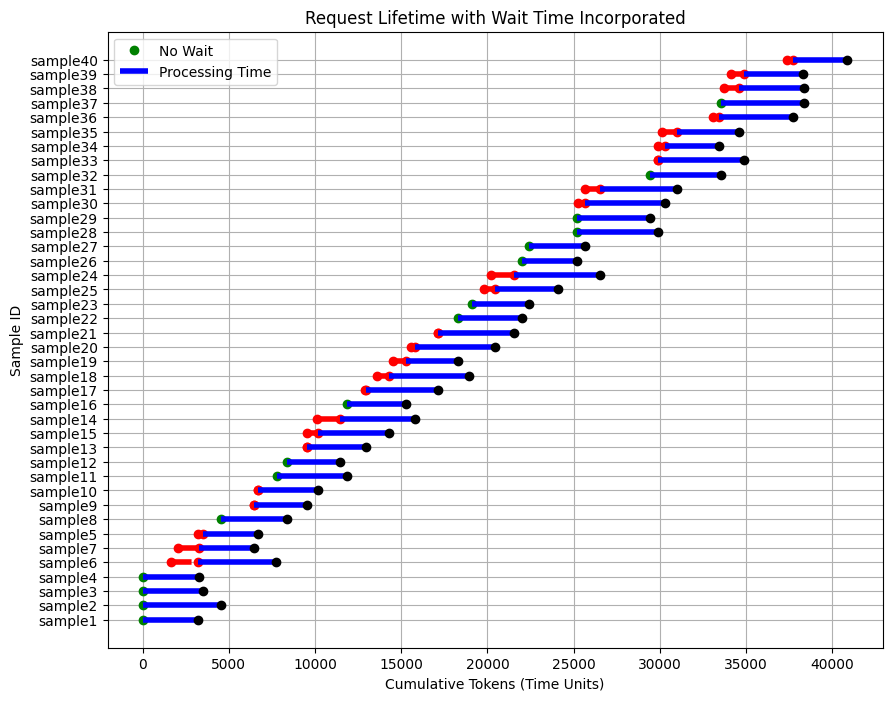

In [72]:
trace = {
    'sample1':  {'prompt': 754, 'max_tokens': 3228, 'arrive_at_step': 0, 'schedule_at_step': 0, 'wait_time': 0},
    'sample2':  {'prompt': 125, 'max_tokens': 4518, 'arrive_at_step': 0, 'schedule_at_step': 0, 'wait_time': 0},
    'sample3':  {'prompt': 381, 'max_tokens': 3501, 'arrive_at_step': 0, 'schedule_at_step': 0, 'wait_time': 0},
    'sample4':  {'prompt': 328, 'max_tokens': 3285, 'arrive_at_step': 0, 'schedule_at_step': 0, 'wait_time': 0},
    'sample5':  {'prompt': 854, 'max_tokens': 3209, 'arrive_at_step': 3229, 'schedule_at_step': 3502, 'wait_time': 273},
    'sample6':  {'prompt': 792, 'max_tokens': 4516, 'arrive_at_step': 1651, 'schedule_at_step': 3229, 'wait_time': 1578},
    'sample7':  {'prompt': 658, 'max_tokens': 3178, 'arrive_at_step': 2070, 'schedule_at_step': 3286, 'wait_time': 1216},
    'sample8':  {'prompt': 704, 'max_tokens': 3864, 'arrive_at_step': 4519, 'schedule_at_step': 4519, 'wait_time': 0},
    'sample9':  {'prompt': 132, 'max_tokens': 3061, 'arrive_at_step': 6439, 'schedule_at_step': 6465, 'wait_time': 26},
    'sample10': {'prompt': 195, 'max_tokens': 3447, 'arrive_at_step': 6681, 'schedule_at_step': 6712, 'wait_time': 31},
    'sample11': {'prompt': 338, 'max_tokens': 4034, 'arrive_at_step': 7803, 'schedule_at_step': 7803, 'wait_time': 0},
    'sample12': {'prompt': 716, 'max_tokens': 3054, 'arrive_at_step': 8384, 'schedule_at_step': 8384, 'wait_time': 0},
    'sample13': {'prompt': 674, 'max_tokens': 3407, 'arrive_at_step': 9501, 'schedule_at_step': 9527, 'wait_time': 26},
    'sample14': {'prompt': 833, 'max_tokens': 4330, 'arrive_at_step': 10129, 'schedule_at_step': 11439, 'wait_time': 1310},
    'sample15': {'prompt': 818, 'max_tokens': 4116, 'arrive_at_step': 9522, 'schedule_at_step': 10160, 'wait_time': 638},
    'sample16': {'prompt': 529, 'max_tokens': 3451, 'arrive_at_step': 11838, 'schedule_at_step': 11838, 'wait_time': 0},
    'sample17': {'prompt': 559, 'max_tokens': 4206, 'arrive_at_step': 12909, 'schedule_at_step': 12935, 'wait_time': 26},
    'sample18': {'prompt': 384, 'max_tokens': 4657, 'arrive_at_step': 13602, 'schedule_at_step': 14277, 'wait_time': 675},
    'sample19': {'prompt': 990, 'max_tokens': 3013, 'arrive_at_step': 14512, 'schedule_at_step': 15290, 'wait_time': 778},
    'sample20': {'prompt': 877, 'max_tokens': 4650, 'arrive_at_step': 15556, 'schedule_at_step': 15770, 'wait_time': 214},
    'sample21': {'prompt': 263, 'max_tokens': 4429, 'arrive_at_step': 17116, 'schedule_at_step': 17142, 'wait_time': 26},
    'sample22': {'prompt': 532, 'max_tokens': 3696, 'arrive_at_step': 18304, 'schedule_at_step': 18304, 'wait_time': 0},
    'sample23': {'prompt': 384, 'max_tokens': 3318, 'arrive_at_step': 19118, 'schedule_at_step': 19118, 'wait_time': 0},
    'sample24': {'prompt': 320, 'max_tokens': 4960, 'arrive_at_step': 20207, 'schedule_at_step': 21572, 'wait_time': 1365},
    'sample25': {'prompt': 881, 'max_tokens': 3689, 'arrive_at_step': 19786, 'schedule_at_step': 20421, 'wait_time': 635},
    'sample26': {'prompt': 204, 'max_tokens': 3189, 'arrive_at_step': 22001, 'schedule_at_step': 22001, 'wait_time': 0},
    'sample27': {'prompt': 489, 'max_tokens': 3198, 'arrive_at_step': 22437, 'schedule_at_step': 22437, 'wait_time': 0},
    'sample28': {'prompt': 467, 'max_tokens': 4735, 'arrive_at_step': 25168, 'schedule_at_step': 25168, 'wait_time': 0},
    'sample29': {'prompt': 452, 'max_tokens': 4236, 'arrive_at_step': 25191, 'schedule_at_step': 25191, 'wait_time': 0},
    'sample30': {'prompt': 370, 'max_tokens': 4652, 'arrive_at_step': 25236, 'schedule_at_step': 25636, 'wait_time': 400},
    'sample31': {'prompt': 144, 'max_tokens': 4494, 'arrive_at_step': 25636, 'schedule_at_step': 26533, 'wait_time': 897},
    'sample32': {'prompt': 570, 'max_tokens': 4098, 'arrive_at_step': 29428, 'schedule_at_step': 29428, 'wait_time': 0},
    'sample33': {'prompt': 227, 'max_tokens': 4992, 'arrive_at_step': 29889, 'schedule_at_step': 29904, 'wait_time': 15},
    'sample34': {'prompt': 487, 'max_tokens': 3161, 'arrive_at_step': 29904, 'schedule_at_step': 30289, 'wait_time': 385},
    'sample35': {'prompt': 665, 'max_tokens': 3600, 'arrive_at_step': 30131, 'schedule_at_step': 31028, 'wait_time': 897},
    'sample36': {'prompt': 949, 'max_tokens': 4287, 'arrive_at_step': 33066, 'schedule_at_step': 33451, 'wait_time': 385},
    'sample37': {'prompt': 733, 'max_tokens': 4813, 'arrive_at_step': 33527, 'schedule_at_step': 33527, 'wait_time': 0},
    'sample38': {'prompt': 982, 'max_tokens': 3740, 'arrive_at_step': 33732, 'schedule_at_step': 34629, 'wait_time': 897},
    'sample39': {'prompt': 691, 'max_tokens': 3393, 'arrive_at_step': 34116, 'schedule_at_step': 34897, 'wait_time': 781},
    'sample40': {'prompt': 821, 'max_tokens': 3142, 'arrive_at_step': 37354, 'schedule_at_step': 37739, 'wait_time': 385}
}
plot(trace)

Index(['request_id', 'arrival_time', 'first_scheduled_time', 'finished_time',
       'stall_times', 'wait_duration', 'time_to_first_token',
       'scheduler_overehad', 'stall_duration', 'decode_length',
       'end_to_end_time', 'time_per_output_token', 'time_between_tokens',
       'stall_durations'],
      dtype='object')
['sample1', 'sample2', 'sample3', 'sample4', 'sample6', 'sample7', 'sample5', 'sample8', 'sample9', 'sample10', 'sample11', 'sample12', 'sample13', 'sample15', 'sample14', 'sample16', 'sample17', 'sample18', 'sample19', 'sample20', 'sample21', 'sample22', 'sample23', 'sample25', 'sample24', 'sample26', 'sample27', 'sample28', 'sample29', 'sample30', 'sample31', 'sample32', 'sample33', 'sample34', 'sample35', 'sample36', 'sample37', 'sample38', 'sample39', 'sample40']
['sample1', 'sample2', 'sample3', 'sample4', 'sample6', 'sample7', 'sample5', 'sample8', 'sample9', 'sample10', 'sample11', 'sample12', 'sample13', 'sample15', 'sample14', 'sample16', 'sample17', 'samp

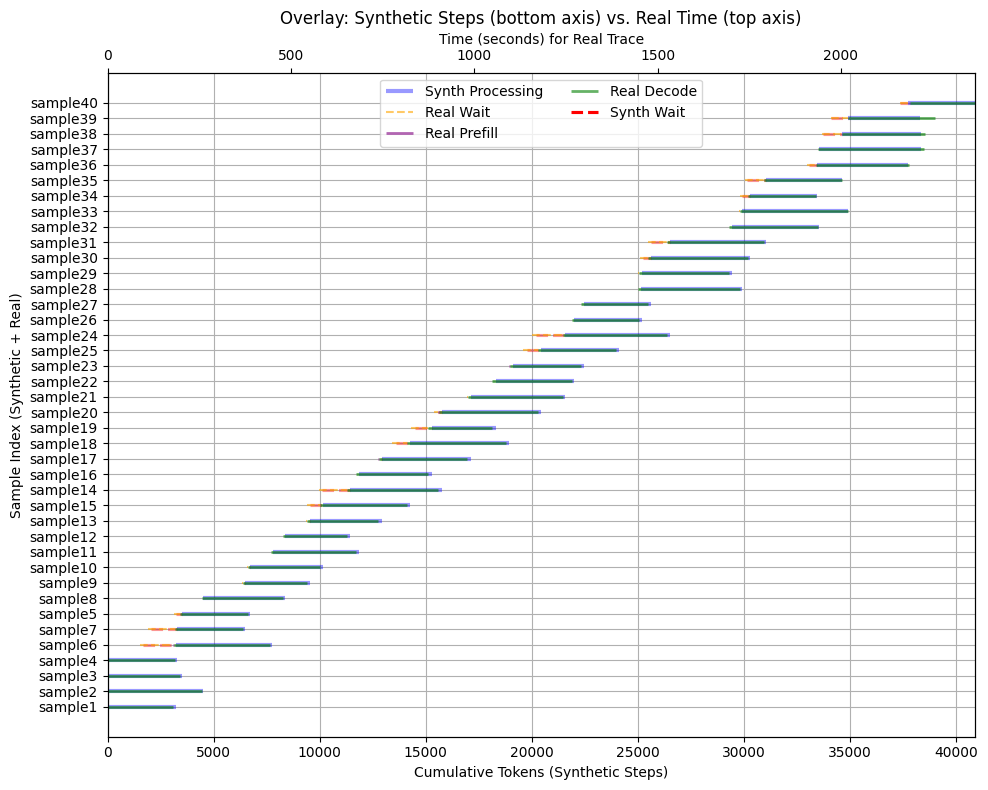

In [83]:
import heapq
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.lines as mlines

def plot_single_figure(DEFAULT_PROMPTS, df):
    """
    DEFAULT_PROMPTS -> your synthetic schedule data
    df              -> your real trace data (pandas DataFrame)
    """
    # ---------------------------------------------------------------------
    # 1) Create the synthetic "step-based" schedule
    # ---------------------------------------------------------------------
    BATCH_SIZE = 4
    heap = []
    simulation_results = {}
    alpha = 0.4
    dash_lw = 1.5 
    solid_lw = 2 
    # Sort by arrival
    sorted_requests = sorted(DEFAULT_PROMPTS.items(), key=lambda x: x[1]["arrive_at_step"])
    for sample_id, sample in sorted_requests:
        arrival = sample["arrive_at_step"]
        processing_time = sample["max_tokens"]

        if len(heap) < BATCH_SIZE:
            actual_start = arrival
        else:
            earliest_finish = heapq.heappop(heap)
            actual_start = max(arrival, earliest_finish)

        finish = actual_start + processing_time
        heapq.heappush(heap, finish)
        
        simulation_results[sample_id] = {
            "arrival": arrival,
            "start": actual_start,
            "finish": finish,
        }

    # For neat plotting: sorted sample IDs by arrival
    synth_ids_sorted = sorted(simulation_results.keys(), 
                              key=lambda sid: simulation_results[sid]["arrival"])
    
    # ---------------------------------------------------------------------
    # 2) Prepare the real-trace data from df
    # ---------------------------------------------------------------------
    # We assume df has columns like: ['request_id', 'arrival_time', 'first_scheduled_time', 
    #  'finished_time', 'time_to_first_token', ...] (as in your code_2 example).
    df['prefill_start'] = df['first_scheduled_time']
    df['prefill_end']   = df['first_scheduled_time'] + df['time_to_first_token']
    df['decode_start']  = df['prefill_end']
    df['decode_end']    = df['finished_time']
    df['wait_start']    = df['arrival_time']
    df['wait_end']      = df['first_scheduled_time']

    df_sorted = df.sort_values(by='arrival_time').reset_index(drop=True)
    
    # Map real-trace request IDs to a y-position
    real_ids_sorted = df_sorted['request_id'].tolist()
    real_id_to_order = {rid: i for i, rid in enumerate(real_ids_sorted)}

    # ---------------------------------------------------------------------
    # 3) Set up intervals for real trace
    #    (We can skip the more advanced 'merge_intervals' if you just want 
    #     to show wait/prefill/decode segments.)
    # ---------------------------------------------------------------------
    requests_info = []
    for idx, row in df_sorted.iterrows():
        rid = row['request_id']
        requests_info.append({
            'request_id': rid,
            'wait_interval':    (row['wait_start'],    row['wait_end']),
            'prefill_interval': (row['prefill_start'], row['prefill_end']),
            'decode_interval':  (row['decode_start'],  row['decode_end'])
        })

    # ---------------------------------------------------------------------
    # 4) Make a single figure with two X axes:
    #    ax1 = bottom axis for "synthetic steps"
    #    ax2 = top axis for "real timeline (seconds)"
    # ---------------------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(10, 8))
    ax2 = ax1.twiny()  # a second axes sharing the same y-axis

    # ---------------------------------------------------------------------
    # 4a) Plot the synthetic schedule on ax1
    # ---------------------------------------------------------------------
    # We'll give these a y-position that doesn't collide with the real data:
    # or if you want to overlay them at the same Y positions, you can re-map
    # them to the same integer y positions (but that might be confusing 
    # unless you have the same sample IDs in both).
    # 
    # Example: We'll just enumerate them in the order we have them:
    y_positions_synth = list(range(len(synth_ids_sorted)))

    synth_wait_legend = mlines.Line2D([], [], color='red', linestyle='dashed', linewidth=dash_lw*1.5, 
                                    label='Synth Wait')
    for y, sample_id in zip(y_positions_synth, synth_ids_sorted):
        res = simulation_results[sample_id]
        arrival = res["arrival"]
        start   = res["start"]
        finish  = res["finish"]

        # Plot wait time if any
        if start > arrival:
            ax1.hlines(y, arrival, start, color='red', linestyle='dashed', linewidth=dash_lw*1.5,
                       label="None" if y==0 else None, alpha=alpha)

        # Plot process time
        ax1.hlines(y, start, finish, color='blue', linewidth=solid_lw*1.5,
                   label="Synth Processing" if y==0 else None, alpha=alpha)

    # Format ax1
    ax1.set_xlabel("Cumulative Tokens (Synthetic Steps)")
    ax1.set_ylabel("Sample Index (Synthetic + Real)")

    # Put the synthetic sample IDs on the left side (just for clarity)
    ax1.set_yticks(y_positions_synth)
    ax1.set_yticklabels(synth_ids_sorted)
    ax1.grid(True)

    # We'll set x-limits for the synthetic steps
    all_starts = [simulation_results[s]["start"] for s in simulation_results]
    all_finishes = [simulation_results[s]["finish"] for s in simulation_results]
    min_step = min(all_starts)
    max_step = max(all_finishes)
    ax1.set_xlim(min_step, max_step)
    print(synth_ids_sorted)

    # ---------------------------------------------------------------------
    # 4b) Plot the real trace on ax2
    # ---------------------------------------------------------------------
    # We'll offset them in the Y dimension so they don't collide, 
    # or overlay them exactly at the same Y positions (but that usually
    # only makes sense if each "sample_id" in synthetic matches "request_id" in real).
    # 
    # For demonstration, let's put the real-trace requests below the synthetic by
    # shifting them by the number of synthetic requests. 
    # So if we have M synthetic requests, we start real data at Y = M + ...
    # (Change as needed!)
    # ---------------------------------------------------------------------
    # y_offset = len(y_positions_synth)
    y_offset = 0
    
    for idx, item in enumerate(requests_info):
        rid = item['request_id']
        y   = y_offset + idx  # shift
        (w_s, w_e) = item['wait_interval']
        (p_s, p_e) = item['prefill_interval']
        (d_s, d_e) = item['decode_interval']

        # Real Wait
        if w_e > w_s:
            ax2.hlines(y, w_s, w_e, color='orange', linestyle='dashed', linewidth=dash_lw,
                       label="Real Wait" if idx==0 else None, alpha=1-alpha)
        # Real Prefill
        if p_e > p_s:
            ax2.hlines(y, p_s, p_e, color='purple', linewidth=solid_lw,
                       label="Real Prefill" if idx==0 else None, alpha=1-alpha)
        # Real Decode
        if d_e > d_s:
            ax2.hlines(y, d_s, d_e, color='green', linewidth=solid_lw,
                       label="Real Decode" if idx==0 else None, alpha=1-alpha)

    # Format ax2
    ax2.set_xlabel("Time (seconds) for Real Trace")
    # Put the real request IDs on the Y ticks for their positions
    real_positions = [y_offset + i for i in range(len(requests_info))]
    ax2.set_yticks(real_positions)
    ax2.set_yticklabels(real_ids_sorted)
    print(real_ids_sorted)
    # We'll set x-limits for the real timeline
    min_time = df['arrival_time'].min()
    max_time = df['finished_time'].max()
    ax2.set_xlim(min_time, max_time)

    # Title, legends, and finishing touches
    ax1.set_title("Overlay: Synthetic Steps (bottom axis) vs. Real Time (top axis)")
    
    # We can combine the legends from both axes:
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    # Combine them with our forced legend item:
    combined_lines  = lines1 + lines2 + [synth_wait_legend]
    combined_labels = labels1 + labels2 + [synth_wait_legend.get_label()]
    # Then call legend on ax1 or ax2
    ax1.legend(combined_lines, combined_labels, loc="upper center", ncol=2)

    ax2.grid(False)  # Usually we let only one axis show the grid
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------
# Usage
# -------------------------------------------------------------
csv_path = "/home/xinyuema/vllm/scripts/metrics.csv"
import pandas as pd 
df = pd.read_csv(csv_path) 
print(df.columns)
df['prefill_start'] = df['first_scheduled_time']
df['prefill_end']   = df['first_scheduled_time'] + df['time_to_first_token']

df['decode_start']  = df['prefill_end']
df['decode_end']    = df['finished_time']

df['wait_start']    = df['arrival_time']
df['wait_end']      = df['first_scheduled_time']
plot_single_figure(trace, df)
